# 1. Forest Classification and Model Selection with Conformal Prediction

## Introduction

In this notebook, we will explore forest classification using ensemble methods and metric models. We will also perform model selection to identify the best-performing model based on various evaluation metrics.

## Objectives

1. **Data Preparation**: Load and preprocess the dataset.
2. **Model Training**: Train Random Forest and Extra Trees classifiers.
3. **Model Evaluation**: Evaluate the performance of each model using metrics such as accuracy, precision, recall, and F1-score.
4. **Hyperparameter Tuning**: Use techniques like Grid Search and Random Search to optimize model parameters.
5. **Model Selection**: Compare the models and select the best one based on evaluation metrics.

In [ ]:
# # !pip3 -q install yellowbrick
# !pip3 -q install imblearn
# !pip3 -q install scienceplots
# !pip3 -q install xgboost
# !pip3 -q install seaborn

In [2]:
#libraries
import pandas as pd
import geopandas as gpd
import numpy as np
import os

#test/train split and hyperparameters optimisation
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GroupShuffleSplit

#ML
from sklearn import preprocessing
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, precision_score, recall_score, cohen_kappa_score 
# from imblearn.over_sampling import SMOTE
from tqdm import tqdm

#xgb
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder


import matplotlib.pyplot as plt


dict_normal_names={7: "Pine", 
        5:"Aspen",
        4: "Larch", 
        1:"Birch",
        6:"Silver fir",
        15:"Burnt forest", 
        13:'Deforestation', 
        14:'Grass',
        12:'Soil', 
        16:'Swamp', 
        11:'Water body',
        17:'Settlements'}

colors =[
    '#117733',
    '#50CE57',
    '#23A28F',
    '#5BD0AE',
    '#88CCEE', 
    '#92462D', 
    '#DE7486',
    '#DDCC77',
    '#AA4499',
    '#0f62fe',
    '#be95ff'
]

#model saving
from joblib import dump, load

In [3]:
import warnings
warnings.filterwarnings('ignore')

## Helpers

In [4]:
def init_models():
    return { 
        "kNN": KNeighborsClassifier(n_jobs=6), 
        "SVC": SVC(probability=True), # to speed up LinearSVC
        "RandomForest": RandomForestClassifier(bootstrap=True, n_jobs=6), 
        "XGB": xgb.XGBClassifier(n_jobs=6)}

In [5]:
def metrics_description(y_true, y_pred, 
                        metrics_by_class: bool=True, 
                        confusion_matrix_multiclass_on: bool=True,
                        binary_matrix_on: bool=False):

    
    print('Accuracy score: %.2f%%' %(accuracy_score(y_true, y_pred)*100))  
    print('Precision score: %.2f%%' % (precision_score(y_true, y_pred, average= 'weighted')*100))
    print('Recall score: %.2f%%' % (recall_score(y_true, y_pred, average= 'weighted')*100))
    print('F1-Score: %.2f%%'%(f1_score(y_true, y_pred, average = 'weighted')*100))
    print('Kappa score: %.2f%%'%(cohen_kappa_score(y_true, y_pred)*100))
    
    
    #dataframe with metrics by class
    if metrics_by_class is True:
        metrics_by_class = pd.DataFrame(
                {
                    'names': list(map(dict_normal_names.get, list(np.unique(y_true)))),
                    'f1_scores': f1_score(y_true, y_pred,
                               average=None).round(2).tolist(),
                    'precision': precision_score(y_true, y_pred, 
                                       average=None).round(2).tolist(),
                    'recall':recall_score(y_true, y_pred,
                                       average=None).round(2).tolist()
                }
            )
        display(metrics_by_class)

    #confusion matrix multiclass
    if confusion_matrix_multiclass_on is True:
        data = confusion_matrix(y_true, y_pred)
        df_cm = pd.DataFrame(data, columns=list(map(dict_normal_names.get, list(np.unique(y_true)))), 
                             index = list(map(dict_normal_names.get, list(np.unique(y_true)))))
        df_cm.index.name = 'Actual'
        df_cm.columns.name = 'Predicted'

        #confusion matrix plot
        f, ax = plt.subplots(figsize=(6, 10))
        cmap = sns.cubehelix_palette(light=1, as_cmap=True)

        sns.heatmap(df_cm, cbar=False, annot=True, cmap=cmap, square=True, fmt='.0f',
                    annot_kws={'size': 10})
        plt.title('Actuals vs Predicted')
        plt.show()
        
    #confusion matrix binary    
    if binary_matrix_on is True:
        cm = confusion_matrix(y_true, y_pred)
        print('Confusion matrix\n\n', cm)
        ConfusionMatrixDisplay(confusion_matrix=cm).plot();

In [6]:
#getting dataset with metrics by class for each random prediction
def get_classes_metrics(models_vector): #vector with model variations, y predicted and y true from the dataset
    class_metrics_dataframe = pd.DataFrame()
    count = 0 #counter of iteration

    for i in models_vector:

        count += 1 #counting
        pred = i['y predicted'] #predicted values 
        true = i['y test data'] #corresponding labels from random test set
        names_list = list(np.unique(true))

        temp = pd.DataFrame(
            {
                'iteration':[count]*len(names_list), 
                'names': list(map(dict_normal_names.get, names_list)),
                'f1_scores': f1_score(true, pred,
                           average=None).round(2).tolist(),
                'precision_list': precision_score(true, 
                                   pred, 
                                   average=None).round(2).tolist(),
                'recall':recall_score(true, 
                                   pred, 
                                   average=None).round(2).tolist()
            }
        ) #dataset for each model 

        class_metrics_dataframe = pd.concat([class_metrics_dataframe, temp], ignore_index=True)
    return class_metrics_dataframe 

In [7]:
def get_metrics_average(models_vector): #vector with model variations, y predicted and y true from the dataset
    average_metrics_dataframe = pd.DataFrame()
    count = 0 #counter of iteration

    for i in models_vector:

        count += 1 #counting
        pred = i['y predicted'] #predicted values 
        true = i['y test data'] #corresponding labels from random test set

        temp = pd.DataFrame(
            {
                'iteration':[count],#*len(names_list), 
                #'names': list(map(dict_normal_names.get, names_list)),
                'f1_scores': f1_score(true, pred,
                           average='weighted').round(2).tolist(),
                'precision_list': precision_score(true, 
                                   pred, 
                                   average='weighted').round(2).tolist(),
                'recall':recall_score(true, 
                                   pred, 
                                   average='weighted').round(2).tolist()
            }
        ) #dataset for each model 

        average_metrics_dataframe = pd.concat([average_metrics_dataframe, temp], 
                                              ignore_index=True)
    return average_metrics_dataframe

In [8]:
def get_best_model(datavector_models):
    number = get_metrics_average(datavector_models).sort_values(by='f1_scores', 
                                                                ascending=False).head(1).reset_index()['index'].values[0]
    best_model = datavector_models[number]['model']
    return best_model

In [9]:
def get_worst_model(datavector_models):
    number = get_metrics_average(datavector_models).sort_values(by='f1_scores', 
                                                                ascending=False).tail(1).reset_index()['index'].values[0]
    best_model = datavector_models[number]['model']
    return best_model

# Data preparation

In [10]:
def get_scaled_data(path:str, cols_remove:list=['key', 'class']):
    df = pd.read_csv(path)
    mask = df['class']!=2
    df=df.loc[mask]
    x = df.drop(columns=cols_remove).values
    #minmax scaling
    min_max_scaler = preprocessing.MinMaxScaler() 
    x_scaled = min_max_scaler.fit_transform(x)
    target_cols = [col for col in list(df.columns) if col not in cols_remove]
    df.loc[:, target_cols] = x_scaled
    return df, min_max_scaler
folder = '../shape_data/filtered_datasets_2024/'
df_scaled, min_max_scaler = get_scaled_data(os.path.join(folder, 'df3_notfiltered.csv'))

In [11]:
def get_random_forest():
    n_estimators = np.arange(100,200,20)
    max_depth = np.arange(10,110,11)
    min_samples_split = [2, 5, 10]
    min_samples_leaf = [1, 2, 4]
    random_grid = {'n_estimators': n_estimators,
                   'max_depth': max_depth,
                   'min_samples_split': min_samples_split,
                   'min_samples_leaf': min_samples_leaf}
    return {"grid":random_grid}

def get_svm():
    svc_grid = {'C': [0.01, 0.1, 10,100], 
              # 'gamma': [1, 0.1, 0.01],
              # 'kernel': ['rbf', 'linear', 'poly']
             }
    return {"grid":svc_grid}
def get_KNN():
    metric = ['euclidean','manhattan','chebyshev','minkowski']
    n_neighbors = np.arange(4,15,2)
    weights = ['uniform','distance']
    random_grid_knn = {'n_neighbors': n_neighbors,
        'weights': weights,
        'metric': metric}
    return {"grid":random_grid_knn}

def get_XGB():
    params = { 'max_depth': [3,6,10],
           "min_child_weight": [0.5, 1, 2],
           'n_estimators': np.arange(10,80,20),
           'colsample_bytree': [0.3, 0.7, 1]}
    return {"grid":params}



## Model training

In [12]:
def model_loop(df_forest: pd.DataFrame, model: str,  param_grid: dict, smote_balance: bool, verbose: int = 0):
    datavector = []
    for i in range(15):
        print(f"{model} ---- {i}")
        trained_model = get_predictions(data = df_forest,
                    model = model,
                    param_grid = param_grid,
                    target_column = 'class',
                    to_remove_columns=['key'],
                    smote_balance=smote_balance,
                    cv=5, 
                    n_iter_search=20, 
                    label_encoder=True if model == 'XGB' else False, 
                    verbose=verbose)
        datavector.append(trained_model)
    return datavector

In [13]:
def check_computed_metrics(metrics: pd.DataFrame, dataset: str, model: str):
    if 'fname' not in metrics:
        return False
    mask = (metrics['fname']==dataset) & (metrics['model']==model) 
    if len(metrics.loc[mask])==150:
        return True
    else:
        return False

In [12]:
metric_fname = '../shape_data/metric_results_v7.csv'
metric_stats_fname = '../shape_data/metric_stats_v7.csv'
if os.path.isfile(metric_fname):
    print('Use cached metrics')
    metric_container = pd.read_csv(metric_fname, index_col=0)
    metric_stats_container = pd.read_csv(metric_stats_fname, index_col=0)
else:
    metric_container = pd.DataFrame()
    metric_stats_container = pd.DataFrame()

Conformal prediction


In [14]:
def print_classes(data):
    print(data.unique())
    print(data.apply(lambda x: dict_normal_names.get(x)).unique())

def get_predictions(data,
                    model,
                    param_grid,
                    target_column: str = 'class',
                    stratify_column: str = 'key',
                    to_remove_columns: list = ['key'],
                    test_size: float=0.3,
                    smote_balance: bool=True,
                    cv: int=5,
                    n_iter_search: int=15,
                    label_encoder: bool=False,
                   verbose: int = 0,):
    #test/train spliting considering key overlap problems and missed classes
    N_JOBS_CV = 1
    if model=='SVC':
        N_JOBS_CV = 4
    n = 0
    while True:
        train_inds, test_inds = next(
            GroupShuffleSplit(
                test_size=test_size, n_splits=2  # ,random_state = 40
            ).split(data, groups=data[stratify_column])
        )
        # because we need pixels from same plots to be separated in train and test
        train = data.iloc[train_inds]
        test = data.iloc[test_inds]

        train_classes = train[target_column].nunique()
        test_classes = test[target_column].nunique()
        all_classes = data[target_column].nunique()
        # because we need classes to be represented in train and test
        n+=1
        if train_classes == test_classes == all_classes:
            break
        if n>40:
            print(f'N - {n}')
            msg= f'Train - {train_classes}, Test = {test_classes}, All - {all_classes}'
            print(msg)
            raise KeyError('Problems in train/test split')
        
    train = train.drop(columns=to_remove_columns)
    test = test.drop(columns=to_remove_columns)

    X_train = train.loc[:, train.columns!=target_column]
    print('X_train.columns', X_train.columns)
    y_train = train[target_column]
    X_test = test.loc[:, train.columns!=target_column]
    y_test = test[target_column]
    model_to_fit = init_models()[model]
    gs = RandomizedSearchCV(estimator=model_to_fit,
                            param_distributions = param_grid,
                            n_iter = n_iter_search,
                            cv = cv,
                            scoring= 'f1_weighted', 
                            verbose=verbose,
                           n_jobs = N_JOBS_CV)
    print('classes in y_train')
    print_classes(y_train)
    print('classes in y_test')
    print_classes(y_test)
    if label_encoder == True:
        le = LabelEncoder()
        gs.fit(X_train, le.fit_transform(y_train))
        y_pred = gs.best_estimator_.predict(X_test)
        model_fit = gs.best_estimator_
        y_proba = gs.best_estimator_.predict_proba(X_test)
        # model_name = gs.best_estimator_.__class__.__name__
        # pd.concat([X_test, y_test, y_pred, y_proba], axis=1).to_csv(f'{model_name}_for_conformal.csv')
        print('classes in y_pred', np.unique(y_pred))
        results = {'model': model_fit,
                   'classes': le.classes_,
            'X_train data': X_train,
            'y train data': y_train,
            'X test data': X_test,
            'y test data': y_test,
            'y predicted': le.inverse_transform(y_pred),
            'y proba': y_proba
            }
    else:
        gs.fit(X_train, y_train)
        y_pred = gs.best_estimator_.predict(X_test)
        print('classes in y_pred', np.unique(y_pred))
        model_fit = gs.best_estimator_
        y_proba = gs.best_estimator_.predict_proba(X_test)
        # model_name = gs.best_estimator_.__class__.__name__
        # pd.concat([X_test, y_test, y_pred, y_proba], axis=1).to_csv(f'{model_name}_for_conformal.csv')

        results = {'model': model_fit,
                   'classes': model_fit.classes_,
                   'X_train data': X_train,
                   'y train data':  y_train,
                   'X test data': X_test,
                   'y test data': y_test,
                   'y predicted': y_pred,
                   'y proba': y_proba

        }
    return results

In [15]:
folder = '../shape_data/filtered_datasets_2024/'
datasets = os.listdir(folder)
problems = []
dataset = 'df3_notfiltered.csv'
smote_balance = False

print(dataset)
scale = dataset[2]
df_scaled, min_max_scaler = get_scaled_data(os.path.join(folder, dataset))    
mask_forest = df_scaled['class']<10
df_forest = df_scaled.loc[mask_forest]

df_forest = df_forest.drop(columns=['B01', 'B11'])

print('Classes in dataset:', df_forest['class'].unique())
models = {
        'RandomForest': get_random_forest(), 
            "SVC":get_svm(),
        "kNN":get_KNN(),
        "XGB":get_XGB()
            }
for model, param_grid in models.items():
    if model != 'SVC':
        continue
    datavector = []
    print(f"{model}")
    trained_model = get_predictions(data = df_forest,
                model = model,
                param_grid = param_grid['grid'],
                target_column = 'class',
                to_remove_columns=['key'],
                smote_balance=smote_balance,
                cv=5, 
                n_iter_search=20, 
                label_encoder=True if model == 'XGB' else False, 
                verbose=0)
    datavector.append(trained_model)
    
    core = dataset.split('.')[0]

    col_names = [f'class_prob_{name}' for name in trained_model['classes']]
    probs_df=pd.DataFrame(trained_model['y proba'], columns=col_names)
    probs_df['observed_class']=trained_model['y test data'].reset_index(drop=True)
    probs_df['predicted_class']=trained_model['y predicted']
    all_df= pd.concat([trained_model['X test data'].reset_index(drop=True), probs_df], axis=1)

    all_df.to_csv(f'conformal_predictions_{model}_{core}.csv', index=False)
    
    best_model = get_best_model(datavector)
    model_path = os.path.join(f'../models/{model}_{core}.joblib')
    dump(best_model, model_path)
    # break

df3_notfiltered.csv
Classes in dataset: [7 5 1 6 4]
SVC
X_train.columns Index(['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B12',
       'NDVI', 'EVI', 'MSAVI', 'NDRE', 'FCI', 'aspect', 'slope',
       'wetnessindex', 'sink', 'ASM1', 'ASM2', 'contrast1', 'contrast2',
       'correlation1', 'correlation2', 'dissimilarity1', 'dissimilarity2',
       'energy1', 'energy2', 'homogeneity1', 'homogeneity2'],
      dtype='object')
classes in y_train
[7 5 1 6 4]
['Pine' 'Aspen' 'Birch' 'Silver fir' 'Larch']
classes in y_test
[7 5 1 4 6]
['Pine' 'Aspen' 'Birch' 'Larch' 'Silver fir']
classes in y_pred [1 4 5 6 7]


In [54]:
df_preds = pd.read_csv(f'conformal_predictions_{model}_{core}.csv')

<Figure size 1000x800 with 0 Axes>

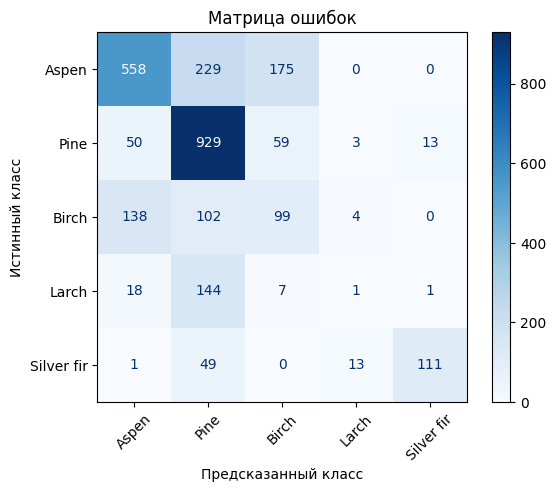

In [55]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Создаем confusion matrix
classes= df_preds['predicted_class'].apply(lambda x: dict_normal_names.get(x)).unique()
cm = confusion_matrix(df_preds['observed_class'], df_preds['predicted_class'], labels=df_preds['predicted_class'].unique())
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, 
                                    display_labels = classes) 
# Создаем тепловую карту
plt.figure(figsize=(10,8))
cm_display.plot(cmap='Blues')
plt.xticks(rotation=45)
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.show()


In [44]:
from sklearn.metrics import f1_score

f1_score(df_preds['observed_class'], df_preds['predicted_class'], average='weighted')

0.682716737091447

## End